# 02 — Ingeniería de variables y minería de texto

**TP Integrador · 82.04 Analítica Descriptiva (ITBA) · Grupo 2 · 2da pre-entrega**

Este notebook responde al segundo punto de la consigna: **uso intensivo de RegEx para
minar las descripciones y extraer el valor oculto en variables booleanas**, más el
cálculo y materialización de todos los KPIs definidos en la 1ra entrega.

El dataset limpio del notebook anterior trae 66 columnas. Doce mil de sus filas tienen
además un campo que ninguna de esas columnas aprovecha: **la descripción del aviso**,
con una mediana de 1.600 caracteres de texto libre donde el vendedor cuenta lo que el
formulario estructurado no captura.

| Sección | Qué se hace |
|---|---|
| 1 | La materia prima: cuánto texto hay y qué contiene |
| 2 | Por qué RegEx y no búsqueda de subcadena — los tres errores del método anterior |
| 3 | Anatomía del motor: patrones, límites de palabra, ventana de negación |
| 4 | Auditoría completa: 35 variables, método viejo contra método nuevo |
| 5 | Variables de estructura recuperadas del texto |
| 6 | Prevalencias y poder discriminante |
| 7 | Los cuatro KPIs, materializados como columnas |

**Reproducir:** `py src/variables.py` y después `py src/kpis.py`

> Este notebook exporta una sola figura, `graficos/04_prevalencias_regex.png`. El
> resto de la narrativa visual vive en el notebook 03, que continúa la numeración
> a partir del 05.


In [1]:
import os, sys, warnings
from pathlib import Path

# El kernel puede arrancar en la raiz del repo o en Entrega 2 (depende del
# editor). Se busca la carpeta notebooks/ para que ../src y ../data resuelvan
# siempre igual, sin importar desde donde se abra el notebook.
def _carpeta_notebooks() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base, base / "Entrega 2"):
            if (cand / "src" / "eda.py").exists():
                return cand / "notebooks"
    raise FileNotFoundError("No se encontro Entrega 2/src: abrir el notebook dentro del repo")

os.chdir(_carpeta_notebooks())
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda
import variables as V
import modelo_alquiler as M
import supuestos as S

eda.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 190)
warnings.filterwarnings("ignore", category=FutureWarning)

df = pd.read_csv("../data/processed/dataset_analitico.csv",
                 encoding="utf-8-sig", low_memory=False)

# El texto se normaliza una sola vez: minusculas, sin tildes, signos como
# espacio. Es exactamente el mismo pipeline que corre variables.py, importado
# desde ahi para que el notebook no pueda divergir del script.
texto = V.construir_texto(df)

print(f"Filas    : {len(df):,}")
print(f"Columnas : {df.shape[1]}")
print(f"Patrones RegEx definidos: {len(V.PATRONES)}")

Filas    : 12,097
Columnas : 98
Patrones RegEx definidos: 35


## 1. La materia prima

Antes de escribir un solo patrón conviene ver con qué se trabaja. La pregunta es si hay
suficiente texto como para que valga la pena minarlo.

In [2]:
largo = texto.str.len()
print("Largo del texto por aviso (titulo + descripcion + detalles):")
print(f"    mediana  {largo.median():>8,.0f} caracteres")
print(f"    media    {largo.mean():>8,.0f}")
print(f"    p10      {largo.quantile(.10):>8,.0f}")
print(f"    p90      {largo.quantile(.90):>8,.0f}")
print(f"    minimo   {largo.min():>8,.0f}")
print(f"    maximo   {largo.max():>8,.0f}")
print()
print(f"Avisos con menos de 200 caracteres: {int((largo < 200).sum()):,} "
      f"({(largo < 200).mean()*100:.1f}%)")
print(f"Palabras totales en el corpus     : {texto.str.split().str.len().sum():,}")

Largo del texto por aviso (titulo + descripcion + detalles):
    mediana     1,599 caracteres
    media       1,742
    p10           872
    p90         2,735
    minimo         37
    maximo     13,911

Avisos con menos de 200 caracteres: 9 (0.1%)
Palabras totales en el corpus     : 3,284,375


In [3]:
# Un aviso de largo mediano, para ver que hay ahi adentro.
i = (largo - largo.median()).abs().idxmin()
print(f"Aviso {df.loc[i, 'id_aviso'][:8]}  —  {df.loc[i, 'barrio']}, "
      f"{df.loc[i, 'operacion']}, {df.loc[i, 'sup_total_m2']:.0f} m2")
print("-" * 74)
t = texto.loc[i]
for k in range(0, min(len(t), 1200), 92):
    print("   ", t[k:k+92])

Aviso 5cf04dde  —  villa lugano, alquiler, 59 m2
--------------------------------------------------------------------------
    barrio copello departamento 3 ambientes corredor publico inmobiliario responsable ana isabel
     gervasoni cpi 7927 todas las propiedades que figuran en mi perfil se encuentran a cargo del
     profesional matriculado de la oficina la intermediacion y la conclusion de las operaciones 
    seran llevadas exclusivamente por el requisitos 1 mes de deposito en garantia 1 mes adelanta
    do seguro de caucion demostrar ingresos la unidad se encuentra en el 8vo piso de la torre 6 
    del barrio copello se ingresa al amplio living comedor con salida al balcon de frente acceso
     a la cocina y 2do balcon ahora cerrado para ampliar el lavadero hacia la izquierda del la e
    ntrada el hall de distribucion desde donde se ingresa a los dos dormitorios con placards emp
    otrados y el bano completo todos los ambientes dan al exterior lo que hace que la unidad sea
   

**Lectura.** Hay material de sobra: la mediana ronda los 1.600 caracteres y menos del
2% de los avisos baja de 200. El texto contiene atributos que el formulario estructurado
no pide —el piso, la orientación, si está alquilado, si acepta mascotas— y que son
justamente los que le interesan al inversor.

El problema no es la disponibilidad del dato. Es cómo se extrae.

## 2. Por qué RegEx y no búsqueda de subcadena

La 1ra entrega ya extraía 21 variables dicotómicas de este mismo texto, con el método más
directo posible: `if "pileta" in texto`. Es rápido de escribir y funciona en la mayoría de
los casos. Pero sobre este corpus produce **tres errores sistemáticos**, y ninguno de los
tres es una rareza estadística: los tres afectan a cientos o miles de avisos.

Los tres se cuantifican abajo con el dataset real.

### 2.1 Error de FRAGMENTO — la keyword vive dentro de otra palabra

`"sum"` estaba en la lista de keywords de `amenities`, por *salón de usos múltiples*.
Pero `"sum"` también es una subcadena de **con-sum-o**, **re-sum-en** y **a-sum-ir**.

In [4]:
# Palabras del castellano corriente que contienen la subcadena "sum"
ruido = texto.str.extractall(r"(\b\w*sum\w+\b)")[0].value_counts()
print("Palabras que contienen 'sum' y NO son el amenity:")
print(ruido.head(12).to_string())
print()
print(f"Avisos afectados: {int(texto.str.contains(r'\b\w*sum\w+\b').sum()):,}")

Palabras que contienen 'sum' y NO son el amenity:
0
consumidor    737
suma          280
sumar         145
sumando       111
sumamente     103
consumo        94
suman          66
resumen        48
suministro     38
consumer       28
sumado         22
sumate         15

Avisos afectados: 1,599


In [5]:
# Cuantos avisos marcaba amenities=1 SOLO por ese fragmento
viejas = pd.DataFrame([V.dummies_viejas(t) for t in texto], index=df.index)

tiene_ruido = texto.str.contains(r"\b\w*sum\w+\b", regex=True)
sin_amenity_real = ~texto.str.contains(
    r"\b(?:amenities|piscina|pileta|solarium|gimnasio|gym|sauna|laundry|coworking)\b",
    regex=True)

falsos = int((viejas.amenities.eq(1) & tiene_ruido & sin_amenity_real).sum())
positivos_viejos = int(viejas.amenities.sum())

print(f"amenities=1 con el metodo viejo        : {positivos_viejos:>6,}")
print(f"de esos, marcados SOLO por el fragmento: {falsos:>6,}")
print(f"tasa de falsos positivos               : {falsos/positivos_viejos*100:>6.1f}%")
print()
print(f"amenities=1 con el metodo RegEx        : {int(df.amenities.sum()):>6,}")

amenities=1 con el metodo viejo        :  4,883
de esos, marcados SOLO por el fragmento:  1,146
tasa de falsos positivos               :   23.5%

amenities=1 con el metodo RegEx        :  5,020


In [6]:
# Un caso concreto, para que no quede en la abstraccion
caso = df.index[viejas.amenities.eq(1) & tiene_ruido & sin_amenity_real][0]
t = texto.loc[caso]
import re as _re
m = _re.search(r".{70}\b\w*sum\w+\b.{40}", t)
print(f"Aviso {df.loc[caso, 'id_aviso'][:8]} — {df.loc[caso, 'barrio']}")
print(f"  ...{m.group(0)}...")
print()
print(f"  metodo viejo -> amenities = {viejas.loc[caso, 'amenities']}")
print(f"  metodo RegEx -> amenities = {df.loc[caso, 'amenities']}   (correcto)")

Aviso 3ae44cfe — caballito
  ...ional 25 028 ley 22 802 de lealtad comercial ley 24 240 de defensa al consumidor las normas del codigo civil y comercial...

  metodo viejo -> amenities = 1
  metodo RegEx -> amenities = 0   (correcto)


> **Por qué importa.** Un 23% de falsos positivos no es ruido inocuo: es una variable
> que le dice al modelo que un departamento tiene pileta y gimnasio porque el aviso
> menciona el consumo de gas.
>
> La corrección es el límite de palabra: `\bsum\b` exige que *sum* sea una palabra
> completa, no un pedazo de otra.

### 2.2 Error de NEGACIÓN — el aviso dice que NO lo tiene

`"la unidad no posee balcón"` contiene la subcadena `"balcon"`. El método viejo marca 1.
El aviso afirma exactamente lo contrario.

In [7]:
ATRIBUTOS = ["balcon", "cochera_txt", "ascensor", "amoblado"]
filas = []
for col in ATRIBUTOS:
    palabra = col.replace("_txt", "")
    negado = texto.str.contains(rf"\b(?:sin|no\s+\w+)\s+{palabra}", regex=True)
    filas.append({
        "atributo": col,
        "avisos que lo niegan": int(negado.sum()),
        "viejo marcaba 1": int((viejas[col].eq(1) & negado).sum()) if col in viejas else np.nan,
        "RegEx marca 1": int((df[col].eq(1) & negado).sum()),
    })
tabla_neg = pd.DataFrame(filas).set_index("atributo")
tabla_neg["corregidos"] = tabla_neg["viejo marcaba 1"] - tabla_neg["RegEx marca 1"]
tabla_neg

,avisos que lo niegan,viejo marcaba 1,RegEx marca 1,corregidos
atributo,,,,
balcon,25,25,5,20
cochera_txt,74,74,42,32
ascensor,21,21,0,21
amoblado,0,0,0,0


In [8]:
# El residuo NO es un fallo del veto: son avisos que niegan el atributo en una
# frase y lo afirman en otra. Se verifica en vez de suponerlo.
for col in ["balcon", "cochera_txt"]:
    palabra = col.replace("_txt", "")
    negado = texto.str.contains(rf"\b(?:sin|no\s+\w+)\s+{palabra}", regex=True)
    resid = df[col].eq(1) & negado
    n = int(resid.sum())
    if n == 0:
        print(f"{col:<14} sin residuo")
        continue
    rx = V.PATRONES[col][0]
    varias = int((texto[resid].str.count(rx) > 1).sum())
    print(f"{col:<14} residuo {n:>3}  ->  {varias}/{n} mencionan el atributo mas de una vez")

print()
ej = df.index[df.cochera_txt.eq(1)
              & texto.str.contains(r"\b(?:sin|no\s+\w+)\s+cochera", regex=True)][0]
t = texto.loc[ej]
print(f"Ejemplo — aviso {df.loc[ej, 'id_aviso'][:8]}:")
for m in _re.finditer(r".{55}cocher.{30}", t):
    print(f"   ...{m.group(0)}...")
print()
print("El aviso niega la cochera propia y despues ofrece una alquilada. El veto")
print("opera por ocurrencia, no por aviso: si el texto lo afirma en algun lado,")
print("la afirmacion vale. Es una decision, no un descuido.")

balcon         residuo   5  ->  5/5 mencionan el atributo mas de una vez
cochera_txt    residuo  42  ->  42/42 mencionan el atributo mas de una vez

Ejemplo — aviso 64c7b153:
   ...ra full amenities alquiler amoblado de 2 ambientes con cochera en palermo hollywood excelen...
   ... 60 metros y posee banera la unidad incluye una amplia cochera cubierta ubicada en el subsu...
   ...del alquiler contrato por 2 anos alquiler amoblado con cochera usd 1 180 mensuales mas gast...
   ... bano cocina living placard orientacion este acceso de cochera rampa fija disposicion frent...

El aviso niega la cochera propia y despues ofrece una alquilada. El veto
opera por ocurrencia, no por aviso: si el texto lo afirma en algun lado,
la afirmacion vale. Es una decision, no un descuido.


> **La ventana de negación es corta a propósito.** Se inspeccionan las tres palabras
> previas al match. Con una ventana larga, `"sin expensas extraordinarias el primer año,
> además cuenta con balcón"` vetaría el balcón por un `sin` que hablaba de otra cosa.
>
> El criterio elegido prefiere dejar pasar una negación lejana antes que vetar un atributo
> real: el falso negativo es más difícil de detectar después que el falso positivo.

### 2.3 Error de ANTÓNIMO — la keyword contiene a su propio opuesto

Este es el peor de los tres, porque no produce ruido: produce **la afirmación contraria**.

La variable `frente` de la 1ra entrega tenía como keywords `["al frente", "contrafrente"]`.
Las dos, en la misma lista. Pero *al frente* y *contrafrente* son atributos **opuestos**:
uno da a la calle y el otro al pulmón de manzana, y en el mercado cotizan distinto.
Además `"contrafrente"` contiene la subcadena `"frente"`, así que ni siquiera hacía falta
que estuviera en la lista.

In [9]:
solo_contra = (texto.str.contains(r"contra\s*frente")
               & ~texto.str.contains(r"\bal\s+frente\b"))
n_mal = int((viejas.frente.eq(1) & solo_contra).sum())

print(f"Avisos que declaran ser contrafrente y NO dicen 'al frente': {int(solo_contra.sum()):,}")
print(f"De esos, el metodo viejo marcaba frente=1                  : {n_mal:,}")
print(f"O sea: {n_mal/max(1,int(viejas.frente.sum()))*100:.1f}% de los positivos de `frente`")
print(f"eran avisos que afirmaban lo contrario.")
print()
print("La variable RegEx no es una dummy: es una categorica de tres valores,")
print("porque el atributo tiene tres estados posibles y no dos.")
print()
print(df.disposicion.value_counts().to_frame("avisos").assign(
    pct=lambda t: (t.avisos / len(df) * 100).round(1)).to_string())

Avisos que declaran ser contrafrente y NO dicen 'al frente': 2,259
De esos, el metodo viejo marcaba frente=1                  : 2,172
O sea: 37.7% de los positivos de `frente`
eran avisos que afirmaban lo contrario.

La variable RegEx no es una dummy: es una categorica de tres valores,
porque el atributo tiene tres estados posibles y no dos.

              avisos   pct
disposicion               
sin dato        5596  46.3
contrafrente    3550  29.3
frente          2951  24.4


## 3. Anatomía del motor

Los 35 patrones viven en `variables.PATRONES`. Cada entrada es una tupla
`(expresión regular, admite negación)`.

In [11]:
muestra = ["pileta", "cochera_txt", "sum", "balcon", "a_reciclar",
           "apto_mascotas", "renta_actual", "estrenar"]
print(f"{'variable':<18}{'nego':<6}patron")
print("-" * 108)
for k in muestra:
    rx, neg = V.PATRONES[k]
    print(f"{k:<18}{'si' if neg else 'no':<6}{rx}")
print()
print(f"Total de patrones : {len(V.PATRONES)}")
print(f"Con veto de negacion: {sum(1 for _, n in V.PATRONES.values() if n)}")
print(f"Ventana de negacion : {V.VENTANA_NEGACION} palabras previas")
print(f"Negadores           : {V.NEGADORES}")

variable          nego  patron
------------------------------------------------------------------------------------------------------------
pileta            si    \b(pileta|piscina|natatorio)\b
cochera_txt       si    \b(cocheras?|garages?|garajes?|estacionamiento|guarda\s*coches?)\b
sum               si    \b(sum|s\s?u\s?m|salon\s+de\s+usos\s+multiples)\b
balcon            si    \b(balcon(es)?|balconcito)\b
a_reciclar        no    \b(a\s+reciclar|a\s+refaccionar|para\s+refaccionar|para\s+reciclar|necesita\s+refaccion|a\s+poner\s+en\s+valor|para\s+remodelar|a\s+demoler)\b
apto_mascotas     si    \b(apto\s+mascotas|acepta\s+mascotas|pet\s+friendly|admite\s+mascotas)\b
renta_actual      no    \b(alquilad[oa]|con\s+inquilino|con\s+renta|renta\s+asegurada|contrato\s+vigente)\b
estrenar          no    \b(a\s+estrenar|sin\s+estrenar|nuevo\s+a\s+estrenar|obra\s+nueva)\b

Total de patrones : 35
Con veto de negacion: 18
Ventana de negacion : 3 palabras previas
Negadores           : (?:sin|no|n

**Por qué algunos patrones no admiten negación.** El veto solo tiene sentido donde el
aviso puede negar el atributo de forma explícita: *sin balcón*, *no apto crédito*. Nadie
escribe *"sin reciclar"* para decir que el departamento no está reciclado, y `"sin estrenar"`
significa justamente **que está a estrenar**. Activar el veto ahí introduciría falsos
negativos en lugar de eliminar falsos positivos.

Ese caso concreto está cubierto por un test de regresión en `test_variables.py`.

In [12]:
# El motor, sobre casos de laboratorio. Es la misma funcion que produjo el dataset.
CASOS = [
    ("departamento con amplio balcon y parrilla", ["balcon", "parrilla"]),
    ("la unidad no posee balcon", ["balcon"]),
    ("bajo consumo de gas natural", ["sum"]),
    ("edificio con SUM y solarium", ["sum", "solarium"]),
    ("departamento sin estrenar", ["estrenar"]),
    ("propiedad a reciclar, apta credito", ["a_reciclar", "reciclado", "apto_credito"]),
    ("bano completo reciclado a nuevo", ["a_reciclar", "reciclado"]),
    ("garaje cubierto y baulera", ["cochera_txt", "baulera"]),
]
for frase, campos in CASOS:
    d = V.extraer_dummies(V.normalizar(frase))
    marcas = "  ".join(f"{k}={d[k]}" for k in campos)
    print(f'  "{frase}"')
    print(f"      -> {marcas}")

  "departamento con amplio balcon y parrilla"
      -> balcon=1  parrilla=1
  "la unidad no posee balcon"
      -> balcon=0
  "bajo consumo de gas natural"
      -> sum=0
  "edificio con SUM y solarium"
      -> sum=1  solarium=1
  "departamento sin estrenar"
      -> estrenar=1
  "propiedad a reciclar, apta credito"
      -> a_reciclar=1  reciclado=0  apto_credito=0
  "bano completo reciclado a nuevo"
      -> a_reciclar=0  reciclado=1
  "garaje cubierto y baulera"
      -> cochera_txt=1  baulera=1


## 4. Auditoría completa: método viejo contra método nuevo

Las 15 variables que existen en los dos métodos, comparadas sobre las mismas 12.097 filas.

In [13]:
comunes = [k for k in viejas.columns if k in df.columns]
filas = []
for k in sorted(comunes):
    v, n = viejas[k], df[k]
    filas.append({
        "variable": k,
        "viejo %": v.mean() * 100,
        "nuevo %": n.mean() * 100,
        "delta pp": (n.mean() - v.mean()) * 100,
        "0 -> 1": int(((v == 0) & (n == 1)).sum()),
        "1 -> 0": int(((v == 1) & (n == 0)).sum()),
    })
comparacion = pd.DataFrame(filas).set_index("variable").round(2)
print(f"Avisos que cambian de valor en al menos una variable: "
      f"{int((viejas[comunes] != df[comunes]).any(axis=1).sum()):,}")
comparacion

Avisos que cambian de valor en al menos una variable: 5,208


,viejo %,nuevo %,delta pp,0 -> 1,1 -> 0
variable,,,,,
a_reciclar,4.32,4.32,0.01,8,7
amenities,40.37,41.50,1.13,1250,1113
amoblado,11.33,7.69,-3.65,423,864
apto_credito,22.58,21.47,-1.12,14,149
ascensor,43.57,43.26,-0.31,2,40
balcon,76.07,63.57,-12.50,0,1512
baulera,15.95,15.94,-0.01,0,1
cochera_txt,30.45,30.62,0.17,80,59
gimnasio,9.90,9.04,-0.86,0,104


### 4.1 Descomposición de las bajas: mudanza contra corrección

La columna `1 -> 0` se lee mal si no se descompone. `balcon` baja 12,5 puntos, y a primera
vista parece que el método nuevo **detecta menos**. No es eso lo que pasa.

Cuando una keyword vieja mezclaba dos conceptos y el RegEx los separa en dos variables, las
filas que pasan de 1 a 0 **no se perdieron: se mudaron**. Hay que descontarlas antes de
hablar de correcciones.

In [14]:
RECATEGORIZADAS = {
    "balcon":   (r"\b(?:terraza|aterrazad)", "terraza",
                 "la keyword vieja de `balcon` incluia 'terraza' y 'aterrazado'"),
    "amoblado": (r"equipad", None,
                 "la keyword vieja incluia 'equipado', que en los avisos califica "
                 "a la cocina, no al departamento"),
}
for k, (rx_mov, destino, motivo) in RECATEGORIZADAS.items():
    baja = (viejas[k] == 1) & (df[k] == 0)
    total = int(baja.sum())
    mudadas = int((baja & texto.str.contains(rx_mov, regex=True)
                   & ~texto.str.contains(rf"\b{k}", regex=True)).sum())
    print(f"{k}")
    print(f"    bajas totales      : {total:>5}")
    print(f"    de esas, mudanza   : {mudadas:>5}  ({mudadas/max(1,total)*100:.1f}%)")
    print(f"    correccion real    : {total - mudadas:>5}")
    print(f"    motivo             : {motivo}")
    if destino:
        print(f"    ahora viven en     : `{destino}` "
              f"({df[destino].mean()*100:.1f}% de prevalencia)")
    print()

balcon
    bajas totales      :  1512
    de esas, mudanza   :  1476  (97.6%)
    correccion real    :    36
    motivo             : la keyword vieja de `balcon` incluia 'terraza' y 'aterrazado'
    ahora viven en     : `terraza` (37.6% de prevalencia)

amoblado
    bajas totales      :   864
    de esas, mudanza   :   856  (99.1%)
    correccion real    :     8
    motivo             : la keyword vieja incluia 'equipado', que en los avisos califica a la cocina, no al departamento



findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

guardado: ../graficos/04_prevalencias_regex.png


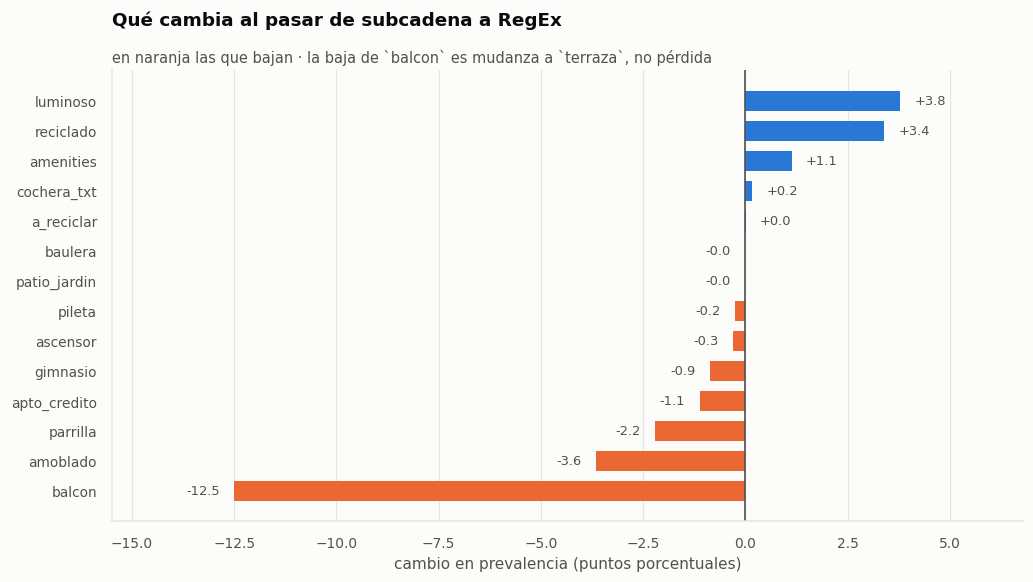

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
comp = comparacion.sort_values("delta pp")
colores = [eda.SERIE_2 if v < 0 else eda.SERIE_1 for v in comp["delta pp"]]
ax.barh(range(len(comp)), comp["delta pp"], color=colores, height=0.66)
ax.axvline(0, color=eda.TINTA_2, linewidth=1.1)
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp.index, fontsize=9)
ax.set_xlabel("cambio en prevalencia (puntos porcentuales)")
eda.sin_grilla_y(ax)
for i, v in enumerate(comp["delta pp"]):
    off = 0.35 if v >= 0 else -0.35
    ax.text(v + off, i, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5, color=eda.TINTA_2)
ax.set_xlim(comp["delta pp"].min() - 3, comp["delta pp"].max() + 3)
eda.titulo(ax, "Qué cambia al pasar de subcadena a RegEx",
           "en naranja las que bajan · la baja de `balcon` es mudanza a `terraza`, no pérdida")
fig.tight_layout()
eda.guardar(fig, 4, "prevalencias_regex")
plt.show()

> **Pregunta que responde el gráfico.** ¿Cuánto mueve cada variable el cambio de método,
> y en qué dirección?
>
> **Lectura.** La mayoría de las variables se mueve menos de 1 punto: el método viejo
> acertaba en el caso común. Las tres excepciones son las interesantes. `balcon` y
> `amoblado` bajan fuerte, pero el bloque de arriba muestra que casi toda esa baja es
> reasignación a otra variable, no detección perdida. `luminoso` y `reciclado` **suben**,
> porque el RegEx captura variantes morfológicas —femeninos, plurales, participios— que
> una lista de keywords literales dejaba pasar.


## 5. Variables de estructura recuperadas del texto

Además de las dicotómicas, el texto contiene información **numérica y categórica** que el
esquema del scraping no captura. Cinco variables nuevas salen de ahí.

In [16]:
ESTRUCTURA = ["piso_txt", "es_planta_baja", "es_ultimo_piso",
              "disposicion", "sup_declarada_txt"]
for col in ESTRUCTURA:
    s = df[col]
    if s.dtype.kind in "if":
        print(f"{col:<20} cobertura {s.notna().mean()*100:>5.1f}%   "
              f"mediana {s.median():>8,.1f}")
    else:
        print(f"{col:<20} cobertura {(s != 'sin dato').mean()*100:>5.1f}%   "
              f"valores: {', '.join(s.unique()[:4])}")

piso_txt             cobertura  39.2%   mediana      1.0
es_planta_baja       cobertura 100.0%   mediana      0.0
es_ultimo_piso       cobertura 100.0%   mediana      0.0
disposicion          cobertura  53.7%   valores: sin dato, frente, contrafrente
sup_declarada_txt    cobertura  50.2%   mediana     60.0


**El caso de `piso_txt` es el más elocuente.** La columna `piso` venía en el esquema del
scraping y se descartó en la limpieza por tener **0,3% de completitud**: el portal casi
nunca la carga. Pero el vendedor sí escribe el piso en la descripción, porque es un dato
que el comprador pregunta.

In [17]:
cob_txt = df.piso_txt.notna().mean() * 100
print(f"Columna `piso` del esquema crudo : 0.3% de completitud (por eso se descarto)")
print(f"Columna `piso_txt` desde el texto: {cob_txt:.1f}% de completitud")
print(f"Ganancia: {cob_txt/0.3:.0f}x")
print()
print("Distribucion de pisos recuperados:")
pisos = df.piso_txt.dropna()
print(pisos.value_counts().sort_index().head(12).to_frame("avisos").T.to_string())
print()
print(f"    planta baja (piso 0): {int((pisos == 0).sum()):,}")
print(f"    ultimo piso marcado : {int(df.es_ultimo_piso.sum()):,}")
print(f"    mediana             : {pisos.median():.0f}")

Columna `piso` del esquema crudo : 0.3% de completitud (por eso se descarto)
Columna `piso_txt` desde el texto: 39.2% de completitud
Ganancia: 131x

Distribucion de pisos recuperados:
piso_txt  0.0   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0
avisos    2065   309   259   278   259   233   220   201   175   139   139   110

    planta baja (piso 0): 2,065
    ultimo piso marcado : 807
    mediana             : 1


In [18]:
# Validacion cruzada: la superficie que dice el TEXTO contra la estructurada.
# Es un control de calidad gratis — si las dos fuentes coinciden, las dos son
# creibles; si divergen mucho, una de las dos esta mal cargada.
amb = df[df.sup_declarada_txt.notna() & df.sup_total_m2.notna()].copy()
amb["dif_pct"] = (amb.sup_declarada_txt - amb.sup_total_m2).abs() / amb.sup_total_m2 * 100

print(f"Avisos con superficie en las dos fuentes: {len(amb):,}")
print()
for u in [1, 5, 10, 25]:
    print(f"    coinciden dentro del {u:>2}%: {(amb.dif_pct <= u).mean()*100:>5.1f}%")
print()
print(f"    diferencia mediana: {amb.dif_pct.median():.1f}%")
print()
print("Las dos fuentes son independientes: una viene del formulario estructurado")
print("del portal y la otra de lo que el vendedor escribio en prosa. Que coincidan")
print("en la mayoria de los casos es evidencia de que ambas son confiables.")

Avisos con superficie en las dos fuentes: 6,070

    coinciden dentro del  1%:  55.4%
    coinciden dentro del  5%:  63.9%
    coinciden dentro del 10%:  67.3%
    coinciden dentro del 25%:  74.7%

    diferencia mediana: 0.7%

Las dos fuentes son independientes: una viene del formulario estructurado
del portal y la otra de lo que el vendedor escribio en prosa. Que coincidan
en la mayoria de los casos es evidencia de que ambas son confiables.


> **Lectura.** La superficie declarada en el texto y la del campo estructurado coinciden
> en la mayoría de los avisos. Eso valida las dos fuentes a la vez, sin costo: son dos
> caminos independientes hacia el mismo dato.
>
> Donde no coinciden suele haber una explicación de negocio —el texto menciona la
> superficie *cubierta* y el campo trae la *total*, o al revés— más que un error. Por eso
> `sup_declarada_txt` se conserva como variable de control y no reemplaza a `sup_total_m2`.

## 6. Prevalencias y poder discriminante

Una dummy solo sirve si divide la muestra. Si el 99% de los avisos la tiene, no explica
ninguna diferencia de precio: es una constante disfrazada de variable.

In [19]:
cols = [k for k in V.PATRONES if k in df.columns]
prev = (df[cols].mean() * 100).sort_values(ascending=False)
tabla_prev = prev.to_frame("% de avisos").assign(
    n=lambda t: (t["% de avisos"] / 100 * len(df)).round(0).astype(int))
print(f"{len(cols)} variables dicotomicas, ordenadas por prevalencia")
tabla_prev

35 variables dicotomicas, ordenadas por prevalencia


,% de avisos,n
balcon,63.569480,7690
luminoso,50.524924,6112
lavadero,45.970075,5561
ascensor,43.258659,5233
aire_acondicionado,41.448293,5014
terraza,37.612631,4550
oportunidad,34.231628,4141
toilette,30.767959,3722
cochera_txt,30.619162,3704
parrilla,28.883194,3494


In [20]:
extremas = prev[(prev < 1) | (prev > 99)]
print("Variables con prevalencia extrema (<1% o >99%):")
if len(extremas) == 0:
    print("    ninguna")
for k, v in extremas.items():
    print(f"    {k:<20}{v:>6.2f}%")
print()
print("Prevalencia cero admite dos lecturas opuestas: el patron no anda, o el")
print("atributo no existe en esta fuente. Se separan probando el patron contra")
print("un texto de laboratorio.")
print()
SONDAS = {"dueno_directo": "vende dueno directo sin comision inmobiliaria"}
for k in extremas.index:
    if k in SONDAS:
        ok = V.extraer_dummies(V.normalizar(SONDAS[k]))[k]
        print(f"    {k:<20} detecta el caso sintetico: {'SI' if ok else 'NO'}")
print()
print("El patron funciona. La prevalencia es cero porque la fuente es una red")
print("inmobiliaria con cartera propia: no publica avisos de particulares. Es una")
print("limitacion de la fuente, no del parseo, y hay que declararla como tal.")

Variables con prevalencia extrema (<1% o >99%):
    dueno_directo         0.04%

Prevalencia cero admite dos lecturas opuestas: el patron no anda, o el
atributo no existe en esta fuente. Se separan probando el patron contra
un texto de laboratorio.

    dueno_directo        detecta el caso sintetico: SI

El patron funciona. La prevalencia es cero porque la fuente es una red
inmobiliaria con cartera propia: no publica avisos de particulares. Es una
limitacion de la fuente, no del parseo, y hay que declararla como tal.


In [21]:
# El indice de confort: cuantos amenities declara cada aviso.
# Es una SUMA simple, no un indice ponderado: ponderar exige reduccion de
# dimensionalidad, que corresponde a la etapa siguiente del trabajo.
print("n_amenities — cuantos de los 15 atributos de confort declara el aviso")
print()
print(df.n_amenities.value_counts().sort_index().to_frame("avisos").T.to_string())
print()
print(f"    mediana {df.n_amenities.median():.0f}   media {df.n_amenities.mean():.2f}   "
      f"maximo {df.n_amenities.max():.0f}")
print(f"    asimetria {df.n_amenities.skew():+.2f}  ->  {eda.leer_asimetria(df.n_amenities.skew())}")

n_amenities — cuantos de los 15 atributos de confort declara el aviso

n_amenities    0     1     2     3     4    5    6    7    8    9    10   11  12  13  14  15
avisos       1252  2302  2343  1881  1155  814  579  511  474  326  211  152  73  19   3   2

    mediana 3   media 3.31   maximo 15
    asimetria +1.09  ->  asimetria fuerte hacia la derecha: la media queda desplazada y hay que leer la mediana


## 7. Los cuatro KPIs, materializados

En la 1ra entrega los KPIs eran definiciones en un informe. Acá dejan de ser fórmulas
escritas y pasan a ser **columnas del dataset, una por propiedad**.

| KPI | Columna | Fórmula |
|---|---|---|
| 1 — Rentabilidad bruta anual | `rent_bruta_pct` | (alquiler estimado × 12) / precio de venta × 100 |
| 2 — Rentabilidad neta anual | `rent_neta_pct` | bruta × (1 − vacancia) × (1 − gastos) |
| 3 — Meses de repago | `meses_repago` | precio de venta / alquiler estimado |
| 4 — Banda de incertidumbre | `rent_bruta_min` / `rent_bruta_max` | bruta × (1 ± error del segmento) |

Ninguno se puede calcular directamente: hay ocho propiedades en venta por cada una en
alquiler, y una propiedad publicada en venta no tiene precio de alquiler observado. 

In [22]:
KPI = ["rent_bruta_pct", "rent_neta_pct", "meses_repago",
       "rent_bruta_min", "rent_bruta_max", "error_estimacion"]
print(f"Filas totales           : {len(df):,}")
print(f"Con KPI calculado       : {int(df.rent_bruta_pct.notna().sum()):,}")
print(f"Sin KPI                 : {int(df.rent_bruta_pct.isna().sum()):,}")
print()
sin = df[df.rent_bruta_pct.isna()]
print("Por que quedan filas sin KPI:")
print(f"    publicadas en alquiler (no tienen precio de venta): "
      f"{int((sin.operacion == 'alquiler').sum()):,}")
print(f"    en venta pero sin superficie o barrio utilizable  : "
      f"{int((sin.operacion == 'venta').sum()):,}")
print()
print("El nulo es la respuesta correcta: una propiedad publicada en alquiler no")
print("tiene precio de venta, asi que su rentabilidad no esta definida. No se imputa.")

Filas totales           : 12,097
Con KPI calculado       : 10,749
Sin KPI                 : 1,348

Por que quedan filas sin KPI:
    publicadas en alquiler (no tienen precio de venta): 1,348
    en venta pero sin superficie o barrio utilizable  : 0

El nulo es la respuesta correcta: una propiedad publicada en alquiler no
tiene precio de venta, asi que su rentabilidad no esta definida. No se imputa.


In [23]:
ok = df[(df.estimacion_confiable == 1) & df.rent_bruta_pct.notna()]
print(f"Base de lectura: {len(ok):,} propiedades en venta con estimacion confiable")
print(f"(se excluyen las de barrios con menos de {M.MIN_ALQ_BARRIO} alquileres, "
      f"donde el modelo extrapola)")
print()
eda.resumen_robusto(ok, KPI)

Base de lectura: 9,203 propiedades en venta con estimacion confiable
(se excluyen las de barrios con menos de 10 alquileres, donde el modelo extrapola)



,n,nulos_%,media,mediana,desvio,IQR,MAD,CV,asimetria,curtosis,p5,p25,p75,p95
variable,,,,,,,,,,,,,,
rent_bruta_pct,9203,0.0,7.41,7.01,2.31,2.33,1.13,0.31,2.89,22.23,4.73,5.98,8.31,11.36
rent_neta_pct,9203,0.0,5.99,5.67,1.87,1.88,0.91,0.31,2.89,22.23,3.83,4.84,6.72,9.19
meses_repago,9203,0.0,174.51,171.00,45.79,57.00,28.00,0.26,0.69,2.28,106.00,144.00,201.00,254.00
rent_bruta_min,9203,0.0,6.40,6.10,1.94,2.02,1.00,0.30,2.61,19.51,4.06,5.20,7.22,9.63
rent_bruta_max,9203,0.0,8.41,7.91,2.70,2.63,1.28,0.32,3.05,23.57,5.35,6.76,9.39,13.05
error_estimacion,9203,0.0,0.13,0.12,0.03,0.05,0.03,0.22,0.11,-1.57,0.10,0.10,0.15,0.17


### 7.1 Lectura de negocio de cada KPI

In [24]:
b, n, m = ok.rent_bruta_pct, ok.rent_neta_pct, ok.meses_repago

print("KPI 1 — RENTABILIDAD BRUTA ANUAL")
print(f"    mediana {b.median():.2f}%   |   p25 {b.quantile(.25):.2f}%   p75 {b.quantile(.75):.2f}%")
print(f"    Es el indicador de cribado: por debajo de {b.quantile(.25):.2f}% la unidad")
print(f"    rinde menos que tres cuartos de la oferta comparable.")
print()
print("KPI 2 — RENTABILIDAD NETA ANUAL")
print(f"    mediana {n.median():.2f}%   |   p25 {n.quantile(.25):.2f}%   p75 {n.quantile(.75):.2f}%")
print(f"    La vacancia y los gastos del propietario se llevan "
      f"{(1 - n.median()/b.median())*100:.1f}% del rendimiento bruto.")
print(f"    Las expensas ordinarias NO se descuentan: en CABA las paga el inquilino.")
print()
print("KPI 3 — MESES DE REPAGO")
print(f"    mediana {m.median():,.0f} meses = {m.median()/12:.1f} años")
print(f"    p25 {m.quantile(.25):,.0f}   p75 {m.quantile(.75):,.0f}")
sosp = int((m < 120).sum())
print(f"    Control de sanidad: {sosp:,} unidades ({sosp/len(ok)*100:.1f}%) repagan en")
print(f"    menos de 10 años. En este mercado eso es inusual y amerita revisar el aviso.")
print(f"    Es un recupero SIMPLE: ignora valor residual, apreciacion e inflacion.")

KPI 1 — RENTABILIDAD BRUTA ANUAL
    mediana 7.01%   |   p25 5.98%   p75 8.31%
    Es el indicador de cribado: por debajo de 5.98% la unidad
    rinde menos que tres cuartos de la oferta comparable.

KPI 2 — RENTABILIDAD NETA ANUAL
    mediana 5.67%   |   p25 4.84%   p75 6.72%
    La vacancia y los gastos del propietario se llevan 19.1% del rendimiento bruto.
    Las expensas ordinarias NO se descuentan: en CABA las paga el inquilino.

KPI 3 — MESES DE REPAGO
    mediana 171 meses = 14.2 años
    p25 144   p75 201
    Control de sanidad: 869 unidades (9.4%) repagan en
    menos de 10 años. En este mercado eso es inusual y amerita revisar el aviso.
    Es un recupero SIMPLE: ignora valor residual, apreciacion e inflacion.


> **Cómo leer el KPI 3.** "Meses de repago" es un **recupero simple**: cuántos meses de
> alquiler estimado hacen falta para igualar el precio de compra. Deja afuera tres cosas
> que en una evaluación de inversión pesan:
>
> - **el valor residual**: al final del período el inversor todavía tiene el inmueble, y el
>   indicador lo trata como si valiera cero;
> - **la apreciación o depreciación** del inmueble en dólares, que el dataset no puede medir
>   porque es un corte único;
> - **la inflación en dólares** y el valor tiempo del dinero: un dólar de alquiler dentro
>   de diez años vale menos que uno hoy, y el indicador los suma como iguales.
>
> Sirve para **comparar propiedades entre sí** a la misma fecha, no como plazo de
> recupero de la inversión ni como sustituto de una TIR.

In [25]:
print("KPI 4 — BANDA DE INCERTIDUMBRE")
print(f"    error mediano aplicado : {ok.error_estimacion.median()*100:.1f}%")
print(f"    ancho mediano de banda : "
      f"{(ok.rent_bruta_max - ok.rent_bruta_min).median():.2f} puntos porcentuales")
print()
print("El error NO es uniforme: crece con la superficie, asi que cada propiedad")
print("recibe la banda de su segmento en vez de una banda unica.")
print()
aux = ok.assign(
    # Los mismos tramos con que el modelo midio su error, leidos de ahi.
    segmento=pd.cut(ok.sup_total_m2, M.BINS_SUP, labels=M.LAB_SUP),
    banda_pp=ok.rent_bruta_max - ok.rent_bruta_min,
)
tabla_err = aux.groupby("segmento", observed=True).agg(
    n=("rent_bruta_pct", "size"),
    error_pct=("error_estimacion", lambda s: s.median() * 100),
    banda_pp=("banda_pp", "median"),
)
print(tabla_err.round(2).to_string())
print()
solapan = int(((ok.rent_bruta_min <= b.median()) & (ok.rent_bruta_max >= b.median())).sum())
print(f"{solapan:,} propiedades ({solapan/len(ok)*100:.1f}%) tienen una banda que contiene")
print(f"la mediana del mercado: su diferencia contra el promedio no se distingue del")
print(f"error de estimacion, y no deberia usarse para decidir entre dos alternativas.")

KPI 4 — BANDA DE INCERTIDUMBRE
    error mediano aplicado : 12.3%
    ancho mediano de banda : 1.78 puntos porcentuales

El error NO es uniforme: crece con la superficie, asi que cada propiedad
recibe la banda de su segmento en vez de una banda unica.

             n  error_pct  banda_pp
segmento                           
<35       1031      10.43      1.50
35-50     2018       9.71      1.34
50-70     2046      12.34      1.66
70-100    1816      15.41      2.10
100+      2292      17.38      2.58

3,834 propiedades (41.7%) tienen una banda que contiene
la mediana del mercado: su diferencia contra el promedio no se distingue del
error de estimacion, y no deberia usarse para decidir entre dos alternativas.


> **Por qué el KPI 4 es el más importante de los cuatro.** El cliente compra **una sola
> unidad** y no puede promediar errores entre varias propiedades. Si dos departamentos
> estiman 7,0% y 7,4% pero los dos tienen una banda de ±12%, la diferencia entre ellos es
> indistinguible del ruido.
>
> Casi la mitad de la oferta cae en esa zona respecto de la mediana del mercado. Una
> recomendación sin intervalo le daría al inversor una falsa sensación de precisión que,
> en su situación, es más peligrosa que la ignorancia.

### 7.2 Supuestos del KPI 2: vacancia y gastos, por separado

La 1ra entrega usaba dos números sueltos, 8% de vacancia y 12% de gastos, sin fuente.
Ahora cada uno se define en `supuestos.py`, con su fuente y su fecha, y los que se
**derivan** se calculan a partir de sus componentes:

- **Vacancia**: fracción del año sin inquilino. Sale del tiempo que tarda en
  re-alquilarse una unidad y de la duración del contrato.
- **Gastos del propietario**: cuatro componentes medidos por separado (administración,
  ABL, expensas extraordinarias y mantenimiento). El modelo recibe un solo número, su suma.

La celda de abajo imprime los valores vigentes y verifica que la columna `rent_neta_pct`
del dataset se haya calculado con ellos, y no con otros.

In [26]:
print(S.tabla())
print()

# La neta materializada tiene que ser la bruta por el factor de supuestos.py.
# Si alguien corrio kpis.py con --vacancia o --gastos a mano, esto lo detecta.
factor = (1 - S.VACANCIA_PCT / 100) * (1 - S.GASTOS_PCT / 100)
esperada = (ok.rent_bruta_pct * factor).round(2)
desvio = (ok.rent_neta_pct - esperada).abs().max()
print(f"Factor neto (1 - vacancia) x (1 - gastos): {factor:.4f}")
print(f"Desvio maximo entre rent_neta_pct y bruta x factor: {desvio:.3f} pp")
print("-> el dataset usa estos supuestos" if desvio <= 0.011
      else "-> ATENCION: el dataset se genero con otros supuestos; reejecutar kpis.py")
print()
print(f"Neta mediana: {ok.rent_neta_pct.median():.2f}%   contra la banda de retorno "
      f"minimo {S.RETORNO_MIN_PISO_PCT:.2f}% a {S.RETORNO_MIN_TECHO_PCT:.2f}% "
      f"(ON corporativas en USD)")
print(f"Propiedades con neta en o sobre el piso: "
      f"{(ok.rent_neta_pct >= S.RETORNO_MIN_PISO_PCT).mean() * 100:.1f}%")

Presupuesto del inversor : USD 80,000 a 200,000

Vacancia                 : 5.88%  (1.5 meses vacios cada contrato de 24)

Gastos del propietario (% del alquiler cobrado):
    administracion       :  4.15%  comision de locacion, Ley 5859
    ABL                  :  3.80%  ARS 32,622/mes sobre USD 573 x 1500
    extraordinarias      :  1.92%  9% de expensas que pesan 21.3%
    mantenimiento        :  4.17%  0.5 mes de alquiler por anio (estimacion propia)
    TOTAL                : 14.04%

Retorno minimo (banda)   : 7.10% a 7.60%  (ON corporativas USD, 2031 a 2037)
    restriccion del analisis, no recomendacion de inversion
    referencia soberana  : 11.65%  (Treasury 10 anios + 641 pb)
Horizonte                : 5 anios  (plazo de la ON del piso)

Factor neto (1 - vacancia) x (1 - gastos): 0.8091
Desvio maximo entre rent_neta_pct y bruta x factor: 0.000 pp
-> el dataset usa estos supuestos

Neta mediana: 5.67%   contra la banda de retorno minimo 7.10% a 7.60% (ON corporativas en USD)
P

> **Lectura.** La banda de retorno mínimo es una **restricción del análisis**, no una
> recomendación: marca lo que rendiría el mismo capital en renta fija en dólares, sin la
> iliquidez del inmueble. Que la neta mediana quede por debajo del piso no dice que
> comprar sea un error, porque el KPI no incluye la apreciación del inmueble. Dice que,
> **solo por renta**, la propiedad mediana no le gana a un bono corporativo, y que la
> decisión depende de la minoría que sí lo hace.

### 7.3 Sensibilidad: ¿cuánto dependen los resultados de estos supuestos?

> **Pregunta.** Si la vacancia o los gastos estuvieran mal estimados, ¿cambiaría la
> conclusión? Se recorre una grilla de vacancia de 4% a 12% y gastos de 8% a 16%, y en
> cada combinación se mira el nivel de la neta, el ranking de barrios y cuántas
> propiedades superan el piso del retorno mínimo. La grilla la calcula `kpis.py`.

In [27]:
sens = pd.read_csv("../data/processed/sensibilidad_supuestos.csv", encoding="utf-8-sig")

def matriz(col):
    m = sens.pivot(index="vacancia_pct", columns="gastos_pct", values=col)
    m.index = [f"vac {v:.0f}%" for v in m.index]
    m.columns = [f"gas {g:.0f}%" for g in m.columns]
    return m

print("Rentabilidad neta mediana (%)")
print(matriz("neta_mediana").to_string())
print()
print(f"Propiedades con neta >= {S.RETORNO_MIN_PISO_PCT:.2f}% (% de la base)")
print(matriz("pct_prop_sobre_piso").to_string())
print()
print(f"Barrios del ranking con neta mediana >= {S.RETORNO_MIN_PISO_PCT:.2f}%")
print(matriz("barrios_sobre_piso").to_string())
print()
rango = sens.neta_mediana.max() - sens.neta_mediana.min()
print(f"Rango de la neta mediana en toda la grilla: {sens.neta_mediana.min():.2f}% a "
      f"{sens.neta_mediana.max():.2f}% ({rango:.2f} pp)")
print(f"Spearman minimo del ranking contra el escenario base: "
      f"{sens.spearman_ranking_vs_base.min():.4f}")
print(f"Top 5 de barrios identico en {int(sens.top5_igual.sum())} de {len(sens)} escenarios")
print(f"Barrios sobre el piso: de {sens.barrios_sobre_piso.max()} en el escenario mas "
      f"favorable a {sens.barrios_sobre_piso.min()} en el mas adverso")

Rentabilidad neta mediana (%)
         gas 8%  gas 10%  gas 12%  gas 14%  gas 16%
vac 4%     6.19     6.06     5.92     5.79     5.65
vac 6%     6.06     5.93     5.80     5.67     5.54
vac 8%     5.93     5.80     5.68     5.55     5.42
vac 10%    5.80     5.68     5.55     5.43     5.30
vac 12%    5.68     5.55     5.43     5.31     5.18

Propiedades con neta >= 7.10% (% de la base)
         gas 8%  gas 10%  gas 12%  gas 14%  gas 16%
vac 4%     29.0     26.3     23.6     21.1     18.7
vac 6%     26.5     23.8     21.4     19.0     17.0
vac 8%     23.8     21.5     19.1     17.1     15.2
vac 10%    21.5     19.3     17.2     15.3     13.6
vac 12%    19.1     17.2     15.3     13.7     12.0

Barrios del ranking con neta mediana >= 7.10%
         gas 8%  gas 10%  gas 12%  gas 14%  gas 16%
vac 4%       10        7        2        1        1
vac 6%        7        2        1        1        1
vac 8%        2        1        1        1        1
vac 10%       1        1        1        1   

> **Lectura.** Los supuestos mueven el **nivel** de la rentabilidad, no el **orden**. El
> ranking de barrios es idéntico en toda la grilla, y eso es por construcción: vacancia y
> gastos se aplican como un mismo factor a todas las propiedades, y multiplicar todo por
> una constante no reordena nada. Dejaría de ser así con una vacancia distinta por barrio,
> que este trabajo no mide.
>
> Donde los supuestos sí pesan es en el **umbral**. La neta mediana se mueve poco en toda
> la grilla, pero la cantidad de barrios que superan el piso del retorno mínimo cae con
> fuerza en cuanto la vacancia o los gastos suben. Los supuestos están justo en la zona
> donde la respuesta a "¿le gana esto a un bono?" cambia. Por eso tienen que estar
> fechados y ser trazables: con esta grilla, quien no esté de acuerdo con un supuesto
> puede ver qué pasa con el suyo.

### 7.4 Control: ¿las variables de texto aportan señal, o solo dimensiones?

Un modelo siempre mejora al agregarle columnas, aunque las columnas sean ruido. La
pregunta correcta no es *"¿sube el R²?"* sino *"¿sube más de lo que subiría con ruido
puro?"*. `kpis.py` responde eso entrenando tres configuraciones sobre los mismos folds.

In [28]:
import re as _re2
reporte = open("../data/processed/reporte_kpis.txt", encoding="utf-8").read()
bloque = reporte.split("CONTROL: LAS DUMMIES DE REGEX, CONTRA RUIDO")[1]
print(bloque.split("=" * 76)[1].strip())

configuracion                                R2 fuera de muestra
----------------------------------------------------------------
dummies de RegEx (las que se usan)                        0.8480
mismas dummies con los valores permutados                 0.8195
sin dummies (todas en cero)                               0.8217

Aporte real de las variables de texto : +0.0263 de R2
Aporte de las mismas columnas al azar : -0.0022 de R2

Lectura: el aporte de las dummies es varias veces mayor que el de
las mismas columnas sin informacion. La mejora viene del contenido
del texto, no de haber agregado columnas.


**Lectura.** Las mismas columnas, con los valores permutados al azar entre filas,
**bajan** el R² respecto de no tenerlas. Eso es lo esperable: conservan la dimensionalidad
y pierden la relación con el precio, así que solo agregan grados de libertad que la
regularización tiene que absorber.

Las dummies reales, en cambio, aportan un salto que es un orden de magnitud mayor. La
mejora viene del **contenido** del texto, no de haber agregado columnas.

Es el control que convierte "usamos RegEx" en una afirmación con evidencia.

## Resumen del notebook

**Lo que entra:** 12.097 avisos con una mediana de 1.600 caracteres de texto libre.

**Lo que sale:**

| Salida | Detalle |
|---|---|
| 35 variables dicotómicas | Patrones con límite de palabra y veto de negación |
| 5 variables de estructura | `piso_txt` (39% de cobertura contra 0,3% del campo original), `es_planta_baja`, `es_ultimo_piso`, `disposicion`, `sup_declarada_txt` |
| 1 índice ordinal | `n_amenities`, suma simple de 15 atributos de confort |
| 4 KPIs materializados | Como columnas, en las 10.749 filas donde están definidos |

El dataset resultante, `dataset_analitico.csv`, es el insumo del notebook 03.
